# Cardiovascular Disease (CVD) Prediction

Predicting the presence of cardiovascular disease from patient health metrics using XGBoost.

**Dataset:** `cardio_train.csv` — 70,000 patient records  
**Target:** `cardio` (1 = has CVD, 0 = no CVD)  
**Pipeline:** Cleaning → Feature Engineering → Train/Test Split → Scaling → Cross-Validation → Evaluation


## 1. Imports

In [7]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


## 2. Load Data

The CSV uses semicolons as delimiters. We use a **relative path** so this notebook
runs on any machine — no hardcoded user paths.


In [8]:
# FIX: use a relative path to the notebook's working directory.
# The CSV is located next to this notebook, not under the empty data/ folder.
df = pd.read_csv('cardio_train.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()


Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Exploratory Data Analysis

Before cleaning, we get a sense of the data: types, missing values, and class balance.


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [10]:
# Age is stored in days — preview what the values look like
print('Age stats (raw, in days):')
print(df['age'].describe())
print()
print('Target balance:')
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True).round(3))


Age stats (raw, in days):
count    70000.000000
mean     19468.865814
std       2467.251667
min      10798.000000
25%      17664.000000
50%      19703.000000
75%      21327.000000
max      23713.000000
Name: age, dtype: float64

Target balance:
cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    0.5
1    0.5
Name: proportion, dtype: float64


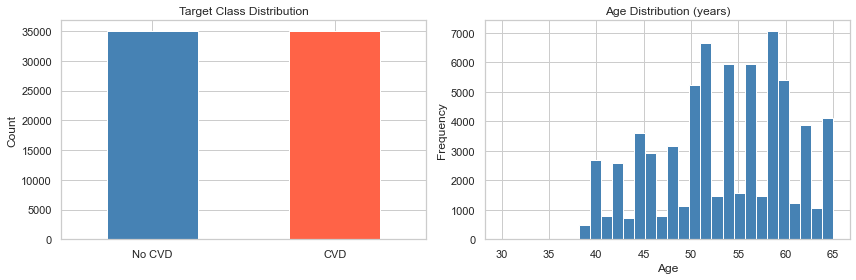

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df['cardio'].value_counts().rename({0: 'No CVD', 1: 'CVD'}).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Age distribution (convert days -> years for readability)
age_years = (df['age'] / 365.25).round().astype(int)
age_years.plot(kind='hist', ax=axes[1], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution (years)')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()


## 4. Data Cleaning

Key steps:
- Convert age from days → years
- Remove duplicate rows (excluding the `id` column)
- Drop rows with biologically impossible clinical values (data entry errors)
- Drop any remaining null rows


In [12]:
# FIX: the original data_cleaning() function called df.dropna() and
# df.drop_duplicates() WITHOUT inplace=True and WITHOUT reassigning the result.
# Those methods return a *new* DataFrame — if you don't capture it, nothing changes.
#
# WRONG (original):   df.dropna()         # result discarded!
# RIGHT:              df = df.dropna()     # reassign to keep the change

df = df.copy()

# Convert age from days to years
df['age'] = (df['age'] / 365.25).round().astype(int)

# Remove duplicate rows (ignore the id column when checking)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'id'])

# Remove rows with biologically impossible clinical values (data entry noise)
df = df[
    df['ap_hi'].between(90, 250)
    & df['ap_lo'].between(60, 180)
    & (df['ap_hi'] > df['ap_lo'])
    & df['height'].between(100, 220)
    & df['weight'].between(30, 200)
    & df['cholesterol'].isin([1, 2, 3])
    & df['gluc'].isin([1, 2, 3])
]

# Drop any remaining nulls
df = df.dropna()

print(f'Rows after cleaning: {len(df):,}')


Rows after cleaning: 64,643


## 5. Feature Engineering

We create clinically meaningful features from the raw measurements:

| Feature | Meaning |
|---|---|
| `bmi` | Body Mass Index — weight/height² |
| `obesity` | BMI ≥ 30 |
| `overweight` | 25 ≤ BMI < 30 |
| `hypertension` | Systolic BP ≥ 140 mmHg |
| `pulse_pressure` | ap_hi − ap_lo (arterial stiffness proxy) |
| `age_bmi` | Interaction term: age × BMI / 100 |
| `cholesterol_gluc_interaction` | Interaction term: cholesterol × gluc |


In [13]:
df['bmi']                         = df['weight'] / (df['height'] / 100) ** 2
df['obesity']                     = (df['bmi'] >= 30).astype(int)
df['overweight']                  = ((df['bmi'] >= 25) & (df['bmi'] < 30)).astype(int)
df['hypertension']                = (df['ap_hi'] >= 140).astype(int)
df['pulse_pressure']              = df['ap_hi'] - df['ap_lo']
df['age_bmi']                     = df['age'] * df['bmi'] / 100
df['cholesterol_gluc_interaction'] = df['cholesterol'] * df['gluc']

print('Top correlations with target:')
print(df.corrwith(df['cardio']).abs().sort_values(ascending=False).head(10))

df.head()


Top correlations with target:
cardio            1.000000
ap_hi             0.426267
hypertension      0.410524
ap_lo             0.342747
pulse_pressure    0.333371
age_bmi           0.260814
age               0.235363
cholesterol       0.213096
bmi               0.177968
weight            0.171984
dtype: float64


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,obesity,overweight,hypertension,pulse_pressure,age_bmi,cholesterol_gluc_interaction
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,0,0,0,30,10.983560,1
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,1,0,1,50,19.210224,3
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,0,0,0,60,12.224059,3
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,0,1,1,50,13.781030,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,0,0,0,40,11.045365,1


## 6. Prepare Features and Target


In [14]:
target   = df['cardio']
features = df.drop(columns=['id', 'cardio', 'height', 'active'])

print('Feature columns:', features.columns.tolist())
print('Shape:          ', features.shape)


Feature columns: ['age', 'gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'bmi', 'obesity', 'overweight', 'hypertension', 'pulse_pressure', 'age_bmi', 'cholesterol_gluc_interaction']
Shape:           (64643, 16)


## 7. Train / Test Split

> ⚠️ **This must happen BEFORE scaling.**
>
> The original code scaled `features` on the *entire* dataset first, then split.
> That means the scaler used statistics (mean, std) computed from the test rows too —
> effectively letting the model peek at test data during training. This is called
> **data leakage** and inflates evaluation scores.
>
> The correct order is: **split → fit scaler on train only → transform both**.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target,   # keeps CVD/non-CVD ratio equal in both splits
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')


Train: (51714, 16)  |  Test: (12929, 16)


## 8. Feature Scaling

We `fit_transform` on the training set and `transform`-only on the test set.
The scaler must never see test data during fitting.

> The original code had three separate scaling issues:
> 1. `scaler.fit_transform(features)` — scaled ALL data before the split (leakage).
> 2. `features = scaler.transform(features)` on the very next line — redundant,
>    the data was already scaled.
> 3. In the final block, the model was trained on unscaled `X_train` but evaluated
>    on scaled `X_test_scaled` — a mismatch that silently distorts predictions.


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from train, then scale
X_test_scaled  = scaler.transform(X_test)         # apply same mean/std to test (no fitting!)


## 9. Cross-Validation

We use a `Pipeline` (scaler + model) inside cross-validation.
This ensures scaling is re-fitted on each fold's training portion only —
the validation fold is never seen during `fit_transform`.

> The original CV loop trained and evaluated correctly in terms of splitting,
> but the features passed in were *already globally scaled* (see step 8 bug),
> which introduced leakage. Using a Pipeline fixes this automatically.


In [17]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        verbosity=0,
        eval_metric='logloss',
    ))
])

sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
cv_auc = cross_val_score(pipeline, features, target, cv=sss, scoring='roc_auc')

print(f'AUC per fold: {cv_auc.round(4)}')
print(f'Mean AUC:     {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')


AUC per fold: [0.7933 0.7954 0.7908 0.7935 0.794  0.7933 0.8009 0.7917 0.7928 0.7993]
Mean AUC:     0.7945 ± 0.0030


## 10. Final Model — Training and Evaluation

Train on the full (scaled) training set, then evaluate on the (scaled) test set.
Both sets are scaled with the **same** scaler fitted on training data only.


In [18]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbosity=0,
    eval_metric='logloss',
)

# FIX: train on X_train_scaled AND evaluate on X_test_scaled — consistent!
# Original code trained on X_train (unscaled) then evaluated on X_test_scaled.
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC:      {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No CVD', 'CVD']))


Accuracy: 0.7264
AUC:      0.7933

              precision    recall  f1-score   support

      No CVD       0.70      0.77      0.73      6344
         CVD       0.75      0.69      0.72      6585

    accuracy                           0.73     12929
   macro avg       0.73      0.73      0.73     12929
weighted avg       0.73      0.73      0.73     12929



## 11. Visualizations

Three standard plots every ML portfolio notebook should include:
confusion matrix, ROC curve, and feature importances.


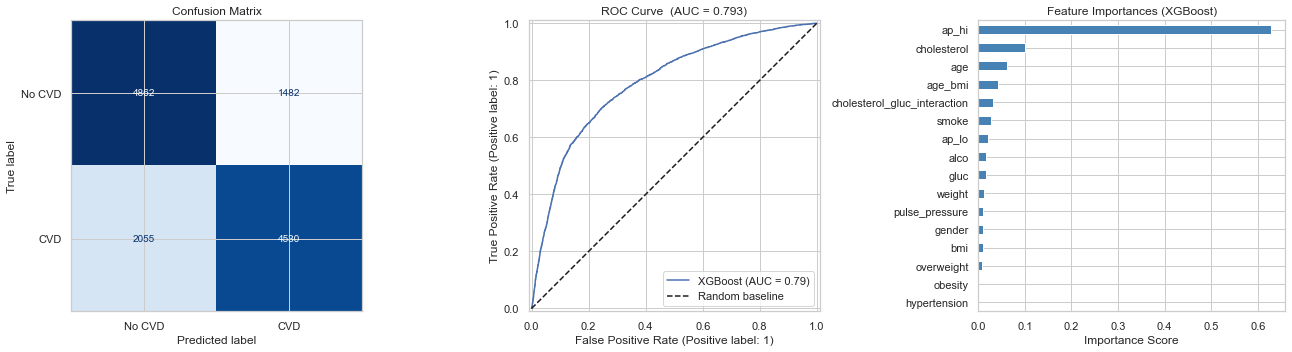

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No CVD', 'CVD']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

# — ROC Curve
auc_score = roc_auc_score(y_test, y_prob)
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='XGBoost')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[1].set_title(f'ROC Curve  (AUC = {auc_score:.3f})')
axes[1].legend()

# — Feature Importance
importances = pd.Series(model.feature_importances_, index=features.columns)
importances.sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importances (XGBoost)')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## 12. Save Model

Save both the trained model and the fitted scaler — you need **both** to make
predictions on new data later.


In [20]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(model,  'models/xgb_cvd_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print('Saved: models/xgb_cvd_model.pkl')
print('Saved: models/scaler.pkl')


Saved: models/xgb_cvd_model.pkl
Saved: models/scaler.pkl
